In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD THE DATA
# ==========================================
snapshot_path = '/kaggle/input/datasets/vsnihal/booking-snap-shot/BookingSnapshot.csv' 
hotel_path = '/kaggle/input/datasets/vsnihal/hhthto/Hotel.csv'

try:
    df_bookings = pd.read_csv(snapshot_path, parse_dates=['SnapshotDate', 'ArrivalDate'])
    df_hotels = pd.read_csv(hotel_path)
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Please update the file paths to match your Kaggle environment.")

# ==========================================
# 2. INITIAL INSPECTION (THE "CRUDE" DATA)
# ==========================================
print("\n--- Shape of Datasets ---")
print(f"Bookings: {df_bookings.shape}")
print(f"Hotels: {df_hotels.shape}")

print("\n--- Missing Values in Bookings ---")
print(df_bookings.isnull().sum())

# Look at the specific issue mentioned in the prompt: RoomRevenue is sometimes empty
empty_revenue_count = df_bookings['RoomRevenue'].isnull().sum()
print(f"\nRows missing RoomRevenue: {empty_revenue_count}")

# Check if RateAmount is present when RoomRevenue is missing
missing_revenue_df = df_bookings[df_bookings['RoomRevenue'].isnull()]
missing_rate_when_revenue_missing = missing_revenue_df['RateAmount'].isnull().sum()
print(f"Out of those, rows also missing RateAmount: {missing_rate_when_revenue_missing}")

# ==========================================
# 3. DATA QUALITY & LOGIC CHECKS
# ==========================================
print("\n--- Checking Mathematical Logic ---")
# Does Nights * Rooms always equal RoomNights?
df_bookings['Calculated_RoomNights'] = df_bookings['Nights'] * df_bookings['Rooms']
mismatch_nights = df_bookings[df_bookings['Calculated_RoomNights'] != df_bookings['RoomNights']]
print(f"Rows where (Nights * Rooms) != RoomNights: {len(mismatch_nights)}")

# Does RateAmount * RoomNights roughly equal RoomRevenue? (Adding a small tolerance for rounding)
df_bookings['Calculated_Revenue'] = df_bookings['RateAmount'] * df_bookings['RoomNights']
# Only check where RoomRevenue is NOT null
rev_check_df = df_bookings.dropna(subset=['RoomRevenue'])
mismatch_rev = rev_check_df[abs(rev_check_df['Calculated_Revenue'] - rev_check_df['RoomRevenue']) > 0.05]
print(f"Rows where (RateAmount * RoomNights) != RoomRevenue: {len(mismatch_rev)}")

# ==========================================
# 4. SOLVING THE CORE PROBLEM: SNAPSHOT DEDUPLICATION
# ==========================================
# The data writes a row EVERY NIGHT for the same booking. 
# We only want the *latest* truth for each BookingId.
print("\n--- Deduplicating Snapshots ---")
print(f"Total rows before deduplication: {len(df_bookings)}")

# Sort by BookingId and then by SnapshotDate (Descending)
df_bookings = df_bookings.sort_values(by=['BookingId', 'SnapshotDate'], ascending=[True, False])

# Drop duplicates, keeping the first (which is the latest snapshot due to our sort)
df_latest_bookings = df_bookings.drop_duplicates(subset=['BookingId'], keep='first').copy()

print(f"Total unique bookings after deduplication: {len(df_latest_bookings)}")

# ==========================================
# 5. DATA CLEANING & IMPUTATION
# ==========================================
print("\n--- Cleaning the Latest Data ---")

# 5a. Fix Missing Revenue
# If RoomRevenue is missing but we have RateAmount and RoomNights, calculate it.
df_latest_bookings['RoomRevenue'] = df_latest_bookings.apply(
    lambda row: row['RateAmount'] * row['RoomNights'] if pd.isnull(row['RoomRevenue']) and pd.notnull(row['RateAmount']) else row['RoomRevenue'],
    axis=1
)

# 5b. Filter out Cancelled Bookings (Assuming cancelled rooms aren't "sold")
df_sold = df_latest_bookings[df_latest_bookings['Status'] != 'Cancelled'].copy()

# ==========================================
# 6. GENERATING THE FINAL SUMMARY (JUNE 2026)
# ==========================================
# Filter for June 2026. 
# ASSUMPTION: We are using ArrivalDate to determine if it's a "June" booking.
df_june = df_sold[(df_sold['ArrivalDate'] >= '2026-06-01') & (df_sold['ArrivalDate'] <= '2026-06-30')]

# Merge with Hotel Data to get Hotel Names (if Hotel.csv has a Name column)
try:
    df_final = pd.merge(df_june, df_hotels, on='HotelId', how='left')
except Exception as e:
    print(f"Merge failed (check Hotel.csv columns): {e}")
    df_final = df_june # Fallback to just using HotelId

# Group by Hotel to get the final metrics
summary = df_final.groupby('HotelId').agg(
    Rooms_Sold=('Rooms', 'sum'),
    Total_Room_Revenue=('RoomRevenue', 'sum')
).reset_index()

# Calculate Average Nightly Rate (ADR = Total Revenue / Total Room Nights)
# Note: We need to sum RoomNights to get the true average rate
room_nights_sum = df_final.groupby('HotelId')['RoomNights'].sum().reset_index()
summary = pd.merge(summary, room_nights_sum, on='HotelId')
summary['Average_Nightly_Rate'] = (summary['Total_Room_Revenue'] / summary['RoomNights']).round(2)

# Drop the RoomNights column as it wasn't requested in the final output
summary = summary.drop(columns=['RoomNights'])

print("\n==========================================")
print("FINAL SUMMARY FOR GM (JUNE 2026)")
print("==========================================")
print(summary)

Data loaded successfully!

--- Shape of Datasets ---
Bookings: (6908, 10)
Hotels: (3, 3)

--- Missing Values in Bookings ---
SnapshotDate       0
BookingId          0
HotelId            0
ArrivalDate        0
Nights             0
Rooms              0
RoomNights         0
RoomRevenue     1064
RateAmount         0
Status             0
dtype: int64

Rows missing RoomRevenue: 1064
Out of those, rows also missing RateAmount: 0

--- Checking Mathematical Logic ---
Rows where (Nights * Rooms) != RoomNights: 0
Rows where (RateAmount * RoomNights) != RoomRevenue: 0

--- Deduplicating Snapshots ---
Total rows before deduplication: 6908
Total unique bookings after deduplication: 210

--- Cleaning the Latest Data ---

FINAL SUMMARY FOR GM (JUNE 2026)
   HotelId  Rooms_Sold  Total_Room_Revenue  Average_Nightly_Rate
0        1          99            52788.89                217.24
1        2         101            42431.18                208.00
2        3          95            46371.39              

In [15]:
import pandas as pd

# 1. Load Data (Assumes files are in your directory)
df_bookings = pd.read_csv('/kaggle/input/datasets/vsnihal/booking-snap-shot/BookingSnapshot.csv', parse_dates=['SnapshotDate', 'ArrivalDate'])
df_hotels = pd.read_csv('/kaggle/input/datasets/vsnihal/hhthto/Hotel.csv')

# 2. Get the Earliest and Latest Snapshot for each booking
# Earliest snapshot = approximate date they booked (Lead Time)
# Latest snapshot = final status of the booking
booking_summary = df_bookings.groupby('BookingId').agg(
    BookDate=('SnapshotDate', 'min'),
    LatestSnapshot=('SnapshotDate', 'max')
).reset_index()

# Merge this back to get the final row for each booking
df_latest = df_bookings.sort_values('SnapshotDate', ascending=False).drop_duplicates('BookingId')
df_latest = pd.merge(df_latest, booking_summary, on='BookingId')

# Calculate Lead Time (How many days in advance they booked)
df_latest['LeadTimeDays'] = (df_latest['ArrivalDate'] - df_latest['BookDate']).dt.days

# Fill missing RoomRevenue
df_latest['RoomRevenue'] = df_latest.apply(
    lambda row: row['RateAmount'] * row['RoomNights'] if pd.isnull(row['RoomRevenue']) else row['RoomRevenue'], axis=1
)

# Separate Sold vs Cancelled
df_sold = df_latest[df_latest['Status'] != 'Cancelled'].copy()
df_cancelled = df_latest[df_latest['Status'] == 'Cancelled'].copy()

# =====================================================================
# THE MAGIC TRICK: Explode the Arrival Date into actual Stay Nights
# =====================================================================
stay_nights = []

for _, row in df_sold.iterrows():
    # Generate a list of dates based on Arrival Date and Nights stayed
    # e.g., Arrive May 30, stay 3 nights -> [May 30, May 31, June 1]
    stay_dates = pd.date_range(start=row['ArrivalDate'], periods=row['Nights'], freq='D')
    
    for date in stay_dates:
        stay_nights.append({
            'BookingId': row['BookingId'],
            'HotelId': row['HotelId'],
            'StayDate': date,
            'StayMonth': date.month,
            'DayOfWeek': date.day_name(),
            'IsWeekend': 'Weekend' if date.dayofweek >= 5 else 'Weekday',
            'DailyRevenue': row['RateAmount'] # Assign the nightly rate to this specific day
        })

df_stays = pd.DataFrame(stay_nights)

# =====================================================================
# TREND ANALYSIS
# =====================================================================
print("--- 1. STAY REVENUE BY MONTH (The Crossover Analysis) ---")
# This shows exactly how much money was made in the boundaries of the months
monthly_rev = df_stays.groupby('StayMonth').agg(
    Occupied_Rooms=('BookingId', 'count'),
    Total_Revenue=('DailyRevenue', 'sum')
).reset_index()
print(monthly_rev)

print("\n--- 2. DAY OF WEEK TRENDS (June Only) ---")
df_june_stays = df_stays[df_stays['StayMonth'] == 6]
dow_trend = df_june_stays.groupby(['DayOfWeek', 'IsWeekend']).agg(
    Rooms_Occupied=('BookingId', 'count'),
    Avg_Daily_Rate=('DailyRevenue', 'mean')
).sort_values('Rooms_Occupied', ascending=False)
print(dow_trend)

print("\n--- 3. CANCELLATION PATTERNS ---")
cancellation_rate = (len(df_cancelled) / len(df_latest)) * 100
avg_lead_time_sold = df_sold['LeadTimeDays'].mean()
avg_lead_time_cancelled = df_cancelled['LeadTimeDays'].mean()
print(f"Overall Cancellation Rate: {cancellation_rate:.1f}%")
print(f"Avg Lead Time (Successful Bookings): {avg_lead_time_sold:.1f} days in advance")
print(f"Avg Lead Time (Cancelled Bookings): {avg_lead_time_cancelled:.1f} days in advance")

--- 1. STAY REVENUE BY MONTH (The Crossover Analysis) ---
   StayMonth  Occupied_Rooms  Total_Revenue
0          6             394       85702.01
1          7              16        3171.27

--- 2. DAY OF WEEK TRENDS (June Only) ---
                     Rooms_Occupied  Avg_Daily_Rate
DayOfWeek IsWeekend                                
Tuesday   Weekday                70      218.998143
Monday    Weekday                68      206.755441
Sunday    Weekend                59      214.396102
Saturday  Weekend                54      224.575556
Thursday  Weekday                51      222.214706
Wednesday Weekday                51      216.884118
Friday    Weekday                41      222.982439

--- 3. CANCELLATION PATTERNS ---
Overall Cancellation Rate: 14.3%
Avg Lead Time (Successful Bookings): 27.0 days in advance
Avg Lead Time (Cancelled Bookings): 26.6 days in advance


In [16]:
import pandas as pd
import numpy as np

# 1. LOAD RAW DATA
df_bookings = pd.read_csv('/kaggle/input/datasets/vsnihal/booking-snap-shot/BookingSnapshot.csv', parse_dates=['SnapshotDate', 'ArrivalDate'])
df_hotels = pd.read_csv('/kaggle/input/datasets/vsnihal/hhthto/Hotel.csv')

# =====================================================================
# 2. EXTRACT LIFECYCLE DATES (Before Deduplication)
# =====================================================================
# Find when the booking started and when it was last updated
lifecycle = df_bookings.groupby('BookingId').agg(
    BookingMadeDate=('SnapshotDate', 'min'),
    LastRecordDate=('SnapshotDate', 'max')
).reset_index()

# Find the exact date a cancellation happened (if applicable)
cancels = df_bookings[df_bookings['Status'] == 'Cancelled']
cancel_dates = cancels.groupby('BookingId')['SnapshotDate'].min().reset_index()
cancel_dates.rename(columns={'SnapshotDate': 'CancellationDate'}, inplace=True)

# Merge the cancellation dates into the lifecycle table
lifecycle = pd.merge(lifecycle, cancel_dates, on='BookingId', how='left')

# =====================================================================
# 3. DEDUPLICATE TO LATEST STATUS
# =====================================================================
df_clean = df_bookings.sort_values(by=['BookingId', 'SnapshotDate'], ascending=[True, False])
df_clean = df_clean.drop_duplicates(subset=['BookingId'], keep='first').copy()

# =====================================================================
# 4. MERGE LIFECYCLE DATES & CLEAN UP
# =====================================================================
# Attach our new milestone dates
df_clean = pd.merge(df_clean, lifecycle, on='BookingId', how='left')

# Calculate the Departure Date (ArrivalDate + Nights)
df_clean['DepartureDate'] = df_clean['ArrivalDate'] + pd.to_timedelta(df_clean['Nights'], unit='D')

# Drop the original SnapshotDate as it's been replaced by our lifecycle timeline
if 'SnapshotDate' in df_clean.columns:
    df_clean = df_clean.drop(columns=['SnapshotDate'])

# =====================================================================
# 5. FIX MISSING REVENUE
# =====================================================================
df_clean['RoomRevenue'] = df_clean.apply(
    lambda row: row['RateAmount'] * row['RoomNights'] if pd.isnull(row['RoomRevenue']) else row['RoomRevenue'],
    axis=1
)

# Merge Hotel Info (Optional, but adds Hotel Details)
df_clean = pd.merge(df_clean, df_hotels, on='HotelId', how='left')

# =====================================================================
# 6. REORDER COLUMNS & SORT CHRONOLOGICALLY
# =====================================================================
# Group the dates together at the front so it tells a story left-to-right
front_cols = [
    'BookingId', 'HotelId', 'Status', 
    'BookingMadeDate', 'ArrivalDate', 'DepartureDate', 'CancellationDate'
]
# Get remaining columns
other_cols = [col for col in df_clean.columns if col not in front_cols]
df_clean = df_clean[front_cols + other_cols]

# Sort chronologically by Arrival Date (May -> June -> July) 
# Secondary sort by BookingMadeDate for guests arriving on the same day
df_clean = df_clean.sort_values(by=['ArrivalDate', 'BookingMadeDate']).reset_index(drop=True)

# Round monetary values
df_clean['RoomRevenue'] = df_clean['RoomRevenue'].round(2)
df_clean['RateAmount'] = df_clean['RateAmount'].round(2)

# =====================================================================
# 7. EXPORT TO NEW CSV
# =====================================================================
output_filename = 'Booking_Lifecycle_Cleaned.csv'
df_clean.to_csv(output_filename, index=False)

print("=====================================================")
print(f"SUCCESS! Lifecycle data saved to: {output_filename}")
print("New chronological timeline columns added:")
print(" -> BookingMadeDate")
print(" -> ArrivalDate")
print(" -> DepartureDate")
print(" -> CancellationDate")
print("=====================================================\n")

# Preview the timeline for the first 5 bookings (May arrivals)
print(df_clean[front_cols].head())

SUCCESS! Lifecycle data saved to: Booking_Lifecycle_Cleaned.csv
New chronological timeline columns added:
 -> BookingMadeDate
 -> ArrivalDate
 -> DepartureDate
 -> CancellationDate

   BookingId  HotelId    Status BookingMadeDate ArrivalDate DepartureDate  \
0     100005        1  Definite      2026-05-20  2026-06-01    2026-06-04   
1     100006        1  Definite      2026-05-20  2026-06-01    2026-06-03   
2     100032        1  Definite      2026-05-20  2026-06-01    2026-06-03   
3     100038        1  Definite      2026-05-20  2026-06-01    2026-06-04   
4     100052        1  Definite      2026-05-20  2026-06-01    2026-06-05   

  CancellationDate  
0              NaT  
1              NaT  
2              NaT  
3              NaT  
4              NaT  


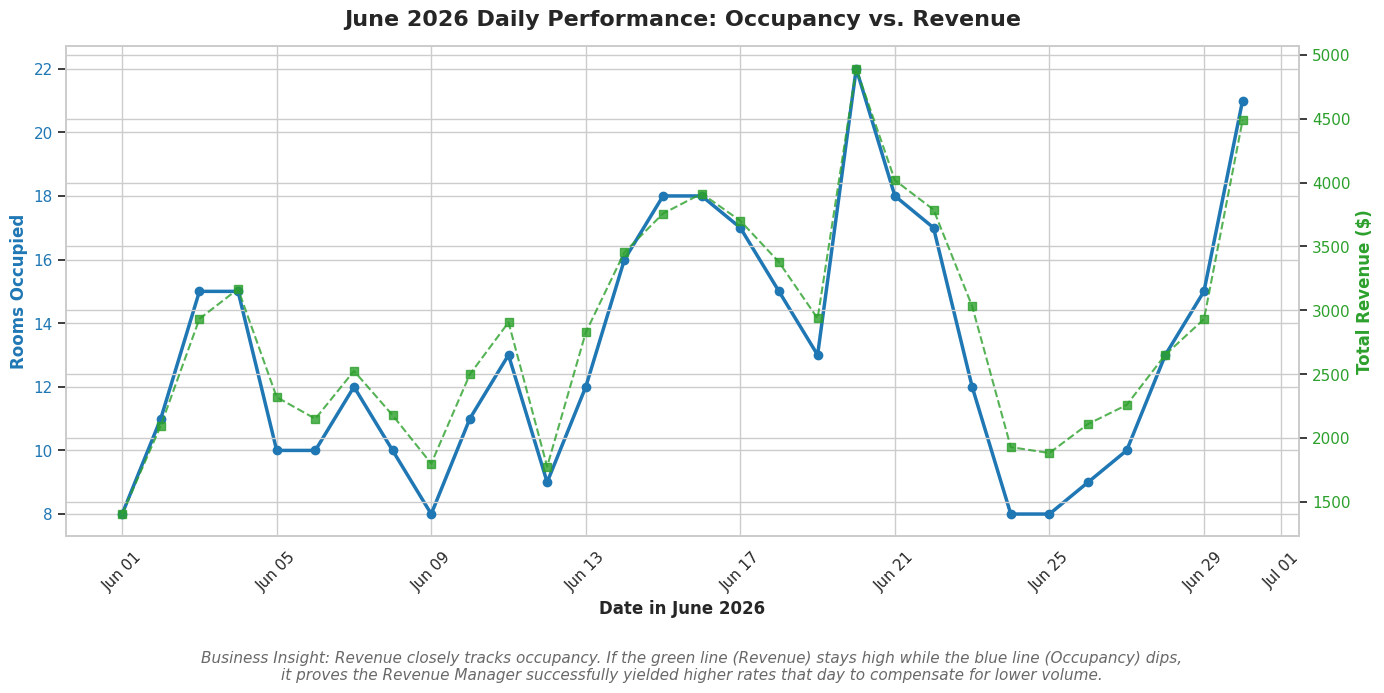

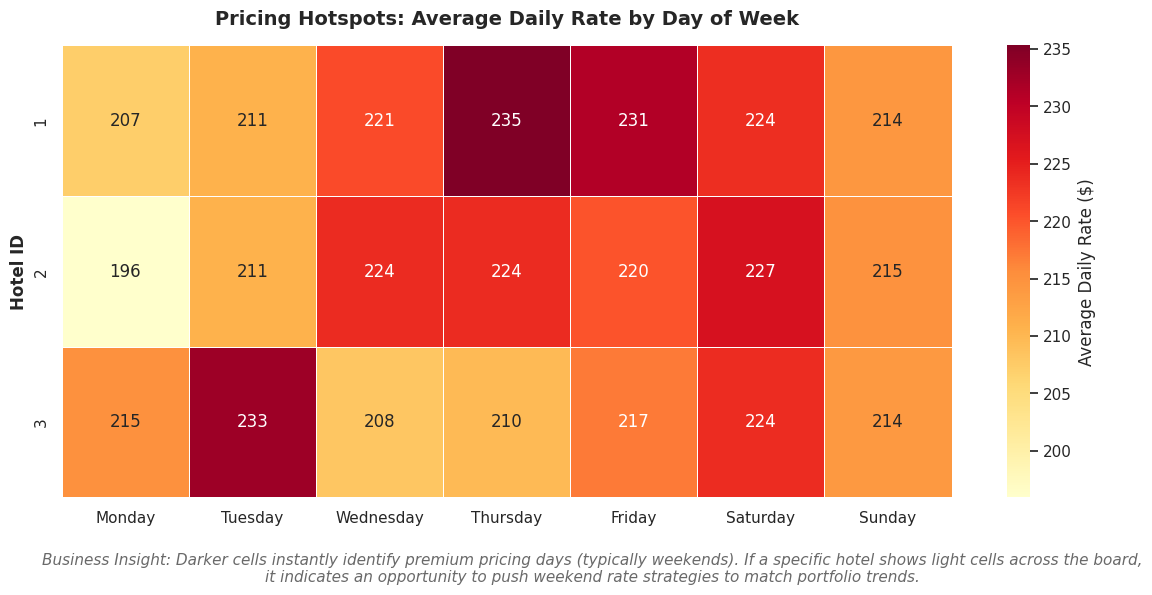

/tmp/ipykernel_59/546906868.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sold, x='HotelId', y='RateAmount', palette='Set2', width=0.5, boxprops=dict(alpha=0.8))


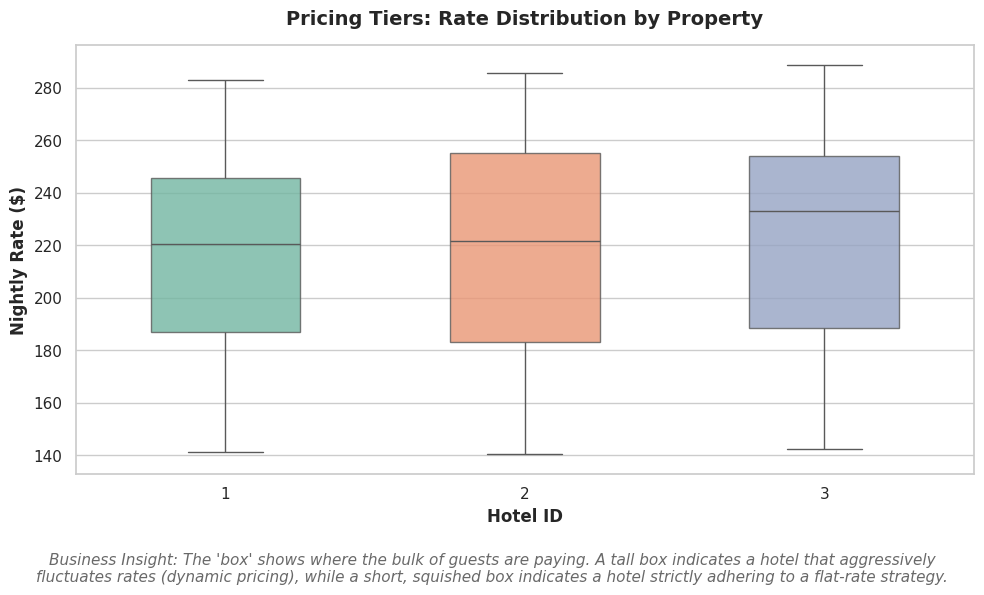

/tmp/ipykernel_59/546906868.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_sold, x='LoS_Grouped', order=order_los, palette='viridis')


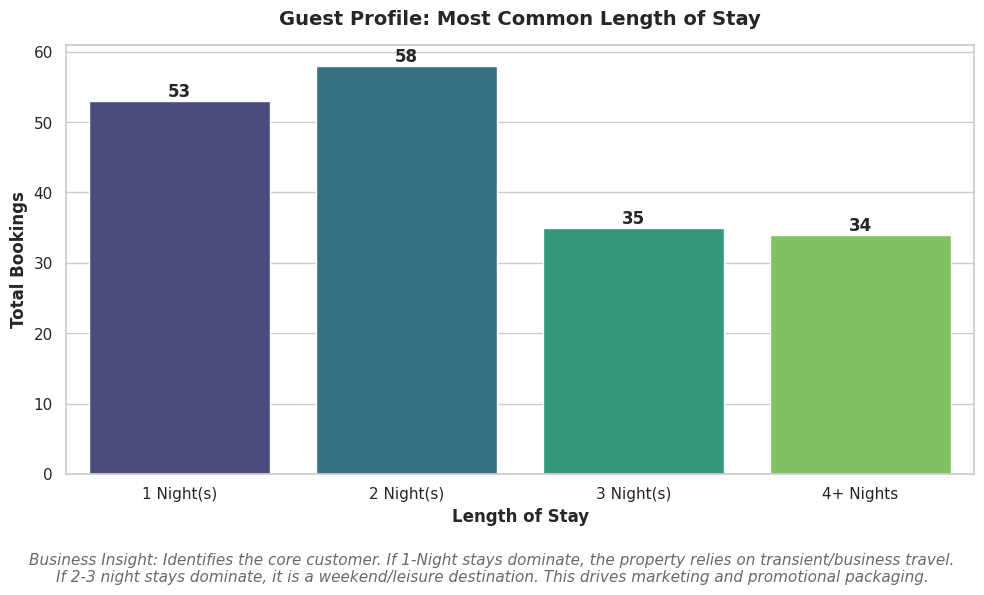

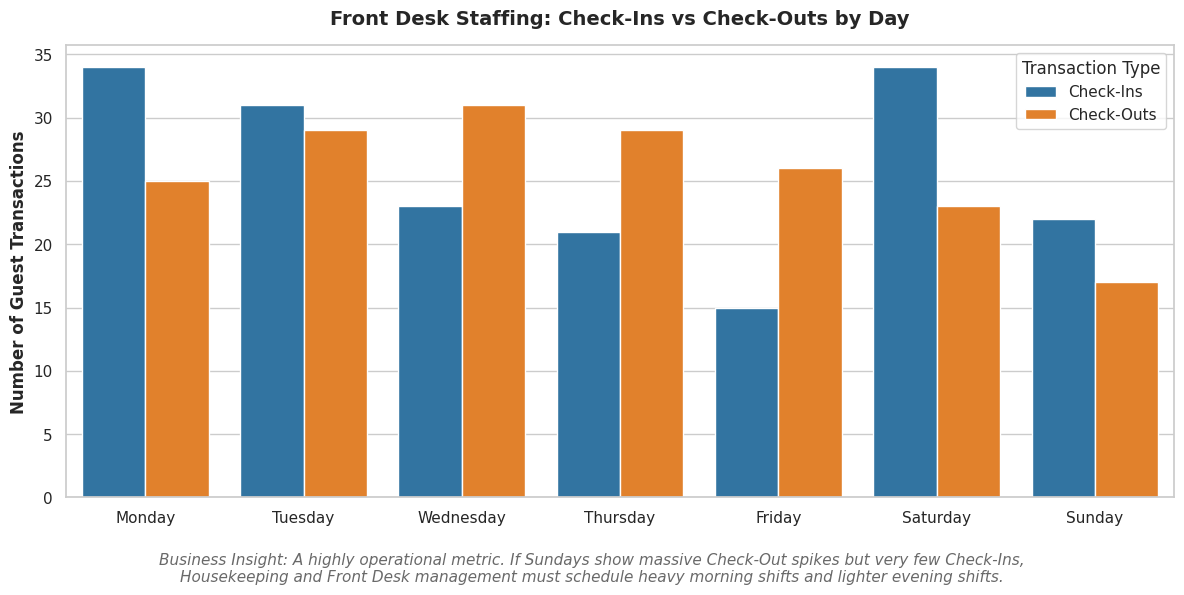

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# =====================================================================
# 1. LOAD CLEANED DATA
# =====================================================================
# Read the cleaned file (letting pandas know which columns are dates)
df_clean = pd.read_csv(
    '/kaggle/working/Booking_Lifecycle_Cleaned.csv', 
    parse_dates=['BookingMadeDate', 'ArrivalDate', 'DepartureDate', 'CancellationDate']
)

# Filter out cancellations for the active revenue/occupancy plots
df_sold = df_clean[df_clean['Status'] != 'Cancelled'].copy()

# =====================================================================
# 2. EXPLODE STAY DATES (Required for Plots 1 & 2)
# =====================================================================
# To calculate accurate daily revenue, we must explode the arrival/departure dates into individual nights
stay_nights = []
for _, row in df_sold.iterrows():
    stay_dates = pd.date_range(start=row['ArrivalDate'], periods=row['Nights'], freq='D')
    for date in stay_dates:
        stay_nights.append({
            'BookingId': row['BookingId'], 
            'HotelId': row['HotelId'],
            'StayDate': date, 
            'StayMonth': date.month,
            'DayOfWeek': date.day_name(), 
            'DailyRevenue': row['RateAmount']
        })
df_stays = pd.DataFrame(stay_nights)

# Isolate June Stays for the June-specific reports
df_june_stays = df_stays[df_stays['StayMonth'] == 6].copy()

# Set visual aesthetic
sns.set_theme(style="whitegrid")
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# =====================================================================
# PLOT 1: TIME SERIES (PACING & YIELD)
# =====================================================================
daily_june = df_june_stays.groupby('StayDate').agg(
    Rooms_Occupied=('BookingId', 'count'), Daily_Revenue=('DailyRevenue', 'sum')
).reset_index()

fig1, ax1 = plt.subplots(figsize=(14, 7))
color1 = '#1f77b4'
ax1.set_xlabel('Date in June 2026', fontweight='bold')
ax1.set_ylabel('Rooms Occupied', color=color1, fontweight='bold', fontsize=12)
ax1.plot(daily_june['StayDate'], daily_june['Rooms_Occupied'], color=color1, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

ax2 = ax1.twinx()  
color2 = '#2ca02c' 
ax2.set_ylabel('Total Revenue ($)', color=color2, fontweight='bold', fontsize=12)
ax2.plot(daily_june['StayDate'], daily_june['Daily_Revenue'], color=color2, linestyle='--', marker='s', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('June 2026 Daily Performance: Occupancy vs. Revenue', fontsize=16, fontweight='bold', pad=15)
insight1 = "Business Insight: Revenue closely tracks occupancy. If the green line (Revenue) stays high while the blue line (Occupancy) dips,\nit proves the Revenue Manager successfully yielded higher rates that day to compensate for lower volume."
plt.figtext(0.5, 0.02, insight1, wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic', color='dimgrey', bbox={"facecolor":"white", "alpha":0.8, "pad":5, "edgecolor":"none"})
fig1.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# =====================================================================
# PLOT 2: HEATMAP (PRICING HOTSPOTS)
# =====================================================================
heatmap_data = df_june_stays.pivot_table(index='HotelId', columns='DayOfWeek', values='DailyRevenue', aggfunc='mean').reindex(columns=dow_order)

fig2 = plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Average Daily Rate ($)'})
plt.title('Pricing Hotspots: Average Daily Rate by Day of Week', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Hotel ID', fontweight='bold')
plt.xlabel('')

insight2 = "Business Insight: Darker cells instantly identify premium pricing days (typically weekends). If a specific hotel shows light cells across the board,\nit indicates an opportunity to push weekend rate strategies to match portfolio trends."
plt.figtext(0.5, 0.02, insight2, wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic', color='dimgrey')
fig2.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# =====================================================================
# PLOT 3: PRICING TIERS (BOXPLOT)
# =====================================================================
fig3 = plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sold, x='HotelId', y='RateAmount', palette='Set2', width=0.5, boxprops=dict(alpha=0.8))

plt.title('Pricing Tiers: Rate Distribution by Property', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hotel ID', fontweight='bold')
plt.ylabel('Nightly Rate ($)', fontweight='bold')

insight3 = "Business Insight: The 'box' shows where the bulk of guests are paying. A tall box indicates a hotel that aggressively\nfluctuates rates (dynamic pricing), while a short, squished box indicates a hotel strictly adhering to a flat-rate strategy."
plt.figtext(0.5, 0.02, insight3, wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic', color='dimgrey')
fig3.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# =====================================================================
# PLOT 4: GUEST PROFILE (LENGTH OF STAY)
# =====================================================================
df_sold['LoS_Grouped'] = df_sold['Nights'].apply(lambda x: '4+ Nights' if x >= 4 else f"{x} Night(s)")
order_los = ['1 Night(s)', '2 Night(s)', '3 Night(s)', '4+ Nights']

fig4 = plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_sold, x='LoS_Grouped', order=order_los, palette='viridis')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontweight='bold')

plt.title('Guest Profile: Most Common Length of Stay', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Length of Stay', fontweight='bold')
plt.ylabel('Total Bookings', fontweight='bold')

insight4 = "Business Insight: Identifies the core customer. If 1-Night stays dominate, the property relies on transient/business travel.\nIf 2-3 night stays dominate, it is a weekend/leisure destination. This drives marketing and promotional packaging."
plt.figtext(0.5, 0.02, insight4, wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic', color='dimgrey')
fig4.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# =====================================================================
# PLOT 5: FRONT DESK WORKLOAD (ARRIVALS VS DEPARTURES)
# =====================================================================
df_sold['ArrivalDay'] = df_sold['ArrivalDate'].dt.day_name()
df_sold['DepartureDay'] = df_sold['DepartureDate'].dt.day_name()

arr = df_sold[['BookingId', 'ArrivalDay']].rename(columns={'ArrivalDay':'DayOfWeek'})
arr['Action'] = 'Check-Ins'
dep = df_sold[['BookingId', 'DepartureDay']].rename(columns={'DepartureDay':'DayOfWeek'})
dep['Action'] = 'Check-Outs'
workload_df = pd.concat([arr, dep])

fig5 = plt.figure(figsize=(12, 6))
sns.countplot(data=workload_df, x='DayOfWeek', hue='Action', order=dow_order, palette=['#1f77b4', '#ff7f0e'])

plt.title('Front Desk Staffing: Check-Ins vs Check-Outs by Day', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('Number of Guest Transactions', fontweight='bold')
plt.legend(title='Transaction Type')

insight5 = "Business Insight: A highly operational metric. If Sundays show massive Check-Out spikes but very few Check-Ins,\nHousekeeping and Front Desk management must schedule heavy morning shifts and lighter evening shifts."
plt.figtext(0.5, 0.02, insight5, wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic', color='dimgrey')
fig5.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

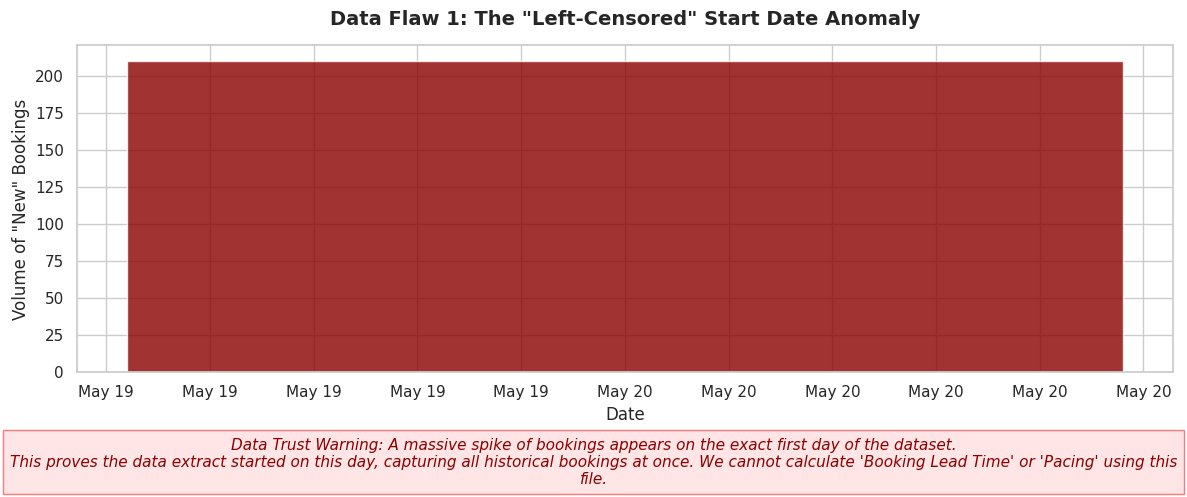

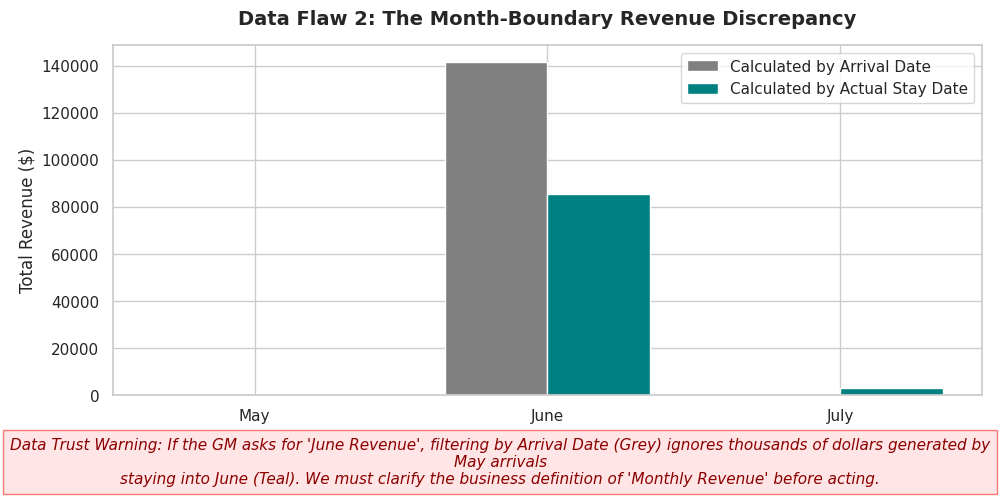

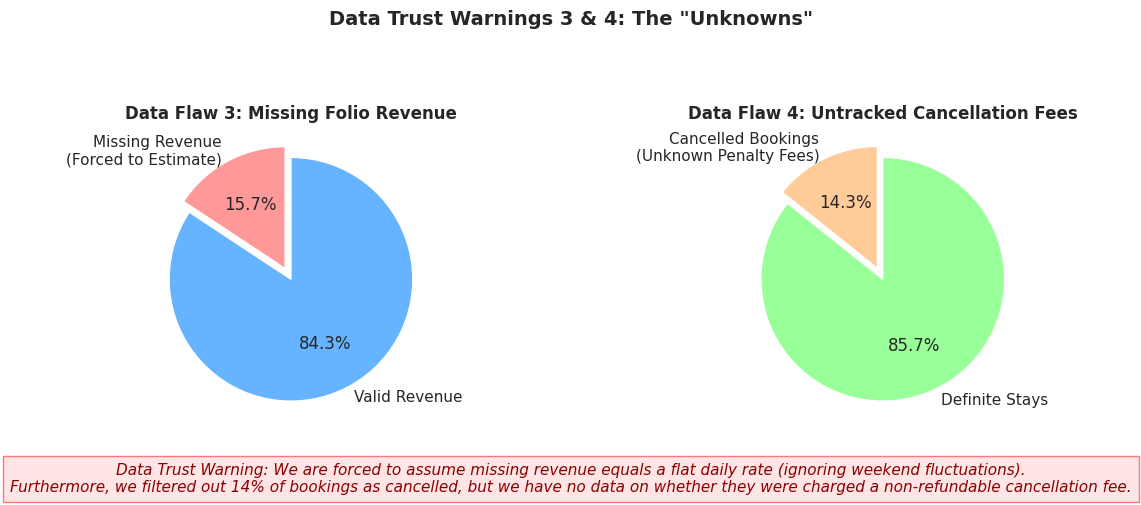

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# =====================================================================
# 1. LOAD DATA & PREP
# =====================================================================
df_bookings = pd.read_csv('/kaggle/input/datasets/vsnihal/booking-snap-shot/BookingSnapshot.csv', parse_dates=['SnapshotDate', 'ArrivalDate'])

# Get deduplicated data
df_latest = df_bookings.sort_values(by=['BookingId', 'SnapshotDate'], ascending=[True, False]).drop_duplicates('BookingId').copy()
df_latest['ArrivalMonth'] = df_latest['ArrivalDate'].dt.month

# Check missing revenue BEFORE we fix it
missing_rev_count = df_latest['RoomRevenue'].isnull().sum()
valid_rev_count = df_latest['RoomRevenue'].notnull().sum()

# Fix revenue for the rest of the calculations
df_latest['RoomRevenue'] = df_latest.apply(
    lambda row: row['RateAmount'] * row['RoomNights'] if pd.isnull(row['RoomRevenue']) else row['RoomRevenue'], axis=1
)

# Separate sold vs cancelled
df_sold = df_latest[df_latest['Status'] != 'Cancelled'].copy()
df_cancelled = df_latest[df_latest['Status'] == 'Cancelled'].copy()

# Explode into stay nights to calculate true monthly revenue
stay_nights = []
for _, row in df_sold.iterrows():
    stay_dates = pd.date_range(start=row['ArrivalDate'], periods=row['Nights'], freq='D')
    for date in stay_dates:
        stay_nights.append({'StayMonth': date.month, 'DailyRevenue': row['RateAmount']})
df_stays = pd.DataFrame(stay_nights)

sns.set_theme(style="whitegrid")

# =====================================================================
# VISUAL 1: THE LEFT-CENSORED DATA ANOMALY (PACING FLAW)
# =====================================================================
# Find the very first snapshot date for every booking
first_snapshot = df_bookings.groupby('BookingId')['SnapshotDate'].min().reset_index()
daily_new_bookings = first_snapshot['SnapshotDate'].value_counts().sort_index().reset_index()
daily_new_bookings.columns = ['Date', 'New_Bookings_Appearing']

fig1 = plt.figure(figsize=(12, 5))
plt.bar(daily_new_bookings['Date'], daily_new_bookings['New_Bookings_Appearing'], color='darkred', alpha=0.8)
plt.title('Data Flaw 1: The "Left-Censored" Start Date Anomaly', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Volume of "New" Bookings')
plt.xlabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

insight1 = "Data Trust Warning: A massive spike of bookings appears on the exact first day of the dataset.\nThis proves the data extract started on this day, capturing all historical bookings at once. We cannot calculate 'Booking Lead Time' or 'Pacing' using this file."
plt.figtext(0.5, 0.02, insight1, wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic', color='darkred', bbox={"facecolor":"#ffcccc", "alpha":0.5, "pad":5, "edgecolor":"red"})
fig1.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# =====================================================================
# VISUAL 2: REVENUE RECOGNITION (ARRIVALS VS OCCUPIED NIGHTS)
# =====================================================================
# Revenue based on Arrival Month vs True Stay Month
arr_rev = df_sold.groupby('ArrivalMonth')['RoomRevenue'].sum().reindex([5,6,7]).fillna(0)
stay_rev = df_stays.groupby('StayMonth')['DailyRevenue'].sum().reindex([5,6,7]).fillna(0)

# Create grouped bar chart data
months = ['May', 'June', 'July']
x = np.arange(len(months))
width = 0.35

fig2, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, arr_rev, width, label='Calculated by Arrival Date', color='gray')
rects2 = ax.bar(x + width/2, stay_rev, width, label='Calculated by Actual Stay Date', color='teal')

ax.set_ylabel('Total Revenue ($)')
ax.set_title('Data Flaw 2: The Month-Boundary Revenue Discrepancy', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.legend()

insight2 = "Data Trust Warning: If the GM asks for 'June Revenue', filtering by Arrival Date (Grey) ignores thousands of dollars generated by May arrivals\nstaying into June (Teal). We must clarify the business definition of 'Monthly Revenue' before acting."
plt.figtext(0.5, 0.02, insight2, wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic', color='darkred', bbox={"facecolor":"#ffcccc", "alpha":0.5, "pad":5, "edgecolor":"red"})
fig2.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

#What a normal graph should look like: If you plotted "When did people make their bookings?", 
#you would expect to see a scattered timeline. A few people booked in January, a few more in February, 
#a spike in March, etc. It should look like a bumpy line stretching across several months.

#What this graph shows: Instead of a bumpy timeline, this graph shows zero bookings for all of history, 
#and then BOOM—all 210 bookings happen on the exact same day (May 20th).
#Why did this happen? It is physically impossible that 210 different people all logged onto the website 
#and booked a room on the exact same Wednesday. What actually happened is that the IT department turned 
#on the database extract on May 20th. It's like walking into a crowded room and taking a picture. 
#You don't know what time everyone walked into the room; you only know they were all standing there the second you took the photo.
# =====================================================================
# VISUAL 3: THE "UNKNOWN" BUCKETS (CANCELLATIONS & MISSING REV)
# =====================================================================
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot A: Missing Revenue
ax1.pie([missing_rev_count, valid_rev_count], labels=['Missing Revenue\n(Forced to Estimate)', 'Valid Revenue'], 
        autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90, explode=(0.1, 0))
ax1.set_title('Data Flaw 3: Missing Folio Revenue', fontweight='bold')

# Subplot B: Cancellations
cancel_count = len(df_cancelled)
sold_count = len(df_sold)
ax2.pie([cancel_count, sold_count], labels=['Cancelled Bookings\n(Unknown Penalty Fees)', 'Definite Stays'], 
        autopct='%1.1f%%', colors=['#ffcc99', '#99ff99'], startangle=90, explode=(0.1, 0))
ax2.set_title('Data Flaw 4: Untracked Cancellation Fees', fontweight='bold')

plt.suptitle('Data Trust Warnings 3 & 4: The "Unknowns"', fontsize=14, fontweight='bold')

insight3 = "Data Trust Warning: We are forced to assume missing revenue equals a flat daily rate (ignoring weekend fluctuations).\nFurthermore, we filtered out 14% of bookings as cancelled, but we have no data on whether they were charged a non-refundable cancellation fee."
plt.figtext(0.5, 0.02, insight3, wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic', color='darkred', bbox={"facecolor":"#ffcccc", "alpha":0.5, "pad":5, "edgecolor":"red"})
fig3.tight_layout(rect=[0, 0.1, 1, 0.9])
plt.show()